# 04 · Sequence Mining (All data)

This notebook mines frequent sequences from user sessions, identifies common patterns, and analyzes sequence characteristics including friction patterns and temporal trends.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx

from analysis.utils import load_all, add_time_features, sessionize

dfs = load_all()
events = dfs['events']
friction = dfs['friction']

# Add time features and sessionize
events = add_time_features(events)
events = sessionize(events, gap_minutes=30)

# Basic session stats
session_stats = {
    'total_sessions': events['session_id'].nunique(),
    'avg_session_length': events.groupby('session_id').size().mean(),
    'median_session_length': events.groupby('session_id').size().median(),
    'avg_session_duration_min': (events.groupby('session_id')['ts'].max() - events.groupby('session_id')['ts'].min()).dt.total_seconds().mean() / 60,
}

print("Session Statistics:")
for k, v in session_stats.items():
    print(f"  {k}: {v:.2f}")


Session Statistics:
  total_sessions: 721.00
  avg_session_length: 12.81
  median_session_length: 5.00
  avg_session_duration_min: 2.46


In [2]:
# Extract sequences from sessions
def extract_sequences(df, min_length=2, max_length=5):
    """Extract sequences of URLs from sessions"""
    sequences = []
    for session_id, session_data in df.groupby('session_id'):
        urls = session_data.sort_values('ts')['url_path'].dropna().tolist()
        if len(urls) >= min_length:
            # Extract all subsequences of length min_length to max_length
            for length in range(min_length, min(max_length + 1, len(urls) + 1)):
                for i in range(len(urls) - length + 1):
                    sequences.append(tuple(urls[i:i+length]))
    return sequences

# Extract sequences
sequences = extract_sequences(events, min_length=2, max_length=4)
sequence_counts = Counter(sequences)

print(f"Total sequences extracted: {len(sequences)}")
print(f"Unique sequences: {len(sequence_counts)}")

# Top frequent sequences
top_sequences = sequence_counts.most_common(20)
print("\nTop 20 sequences:")
for seq, count in top_sequences:
    print(f"  {count:3d}x: {' → '.join(seq)}")


Total sequences extracted: 23855
Unique sequences: 3492

Top 20 sequences:
  1272x: http://localhost:3000/dashboard → http://localhost:3000/dashboard
  1217x: http://localhost:3000/dashboard → http://localhost:3000/dashboard → http://localhost:3000/dashboard
  1167x: http://localhost:3000/dashboard → http://localhost:3000/dashboard → http://localhost:3000/dashboard → http://localhost:3000/dashboard
  466x: https://www.linkedin.com/feed/ → https://www.linkedin.com/feed/
  431x: https://www.linkedin.com/feed/ → https://www.linkedin.com/feed/ → https://www.linkedin.com/feed/
  407x: https://www.linkedin.com/feed/ → https://www.linkedin.com/feed/ → https://www.linkedin.com/feed/ → https://www.linkedin.com/feed/
  335x: https://github.com/OmMistry25 → https://github.com/OmMistry25
  286x: https://github.com/OmMistry25 → https://github.com/OmMistry25 → https://github.com/OmMistry25
  260x: https://www.youtube.com/ → https://www.youtube.com/
  248x: https://www.google.com/search → https://www

In [3]:
# Analyze friction patterns in sequences
def is_friction_event(row):
    t = str(row.get('type', '')).lower()
    return ('friction' in t) or ('rage' in t)

events['is_friction'] = events.apply(is_friction_event, axis=1)

# Find sequences with high friction rates
def analyze_sequence_friction(df, sequences, min_count=5):
    """Analyze friction rates for each sequence"""
    seq_friction = {}
    
    for session_id, session_data in df.groupby('session_id'):
        urls = session_data.sort_values('ts')['url_path'].dropna().tolist()
        friction_flags = session_data.sort_values('ts')['is_friction'].tolist()
        
        # Check each sequence
        for length in range(2, 5):
            for i in range(len(urls) - length + 1):
                seq = tuple(urls[i:i+length])
                friction_in_seq = friction_flags[i:i+length]
                
                if seq not in seq_friction:
                    seq_friction[seq] = {'total': 0, 'friction_count': 0, 'friction_events': 0}
                
                seq_friction[seq]['total'] += 1
                seq_friction[seq]['friction_count'] += any(friction_in_seq)
                seq_friction[seq]['friction_events'] += sum(friction_in_seq)
    
    # Calculate friction rates
    friction_analysis = []
    for seq, stats in seq_friction.items():
        if stats['total'] >= min_count:
            friction_analysis.append({
                'sequence': ' → '.join(seq),
                'length': len(seq),
                'total_occurrences': stats['total'],
                'sessions_with_friction': stats['friction_count'],
                'total_friction_events': stats['friction_events'],
                'friction_session_rate': stats['friction_count'] / stats['total'],
                'avg_friction_events_per_session': stats['friction_events'] / stats['total']
            })
    
    return pd.DataFrame(friction_analysis).sort_values('friction_session_rate', ascending=False)

friction_analysis = analyze_sequence_friction(events, sequences, min_count=3)
print("Top sequences by friction session rate:")
friction_analysis.head(15)


Top sequences by friction session rate:


,sequence,length,total_occurrences,sessions_with_friction,total_friction_events,friction_session_rate,avg_friction_events_per_session
837,https://observeandcreate-2mbqsiyxv-ommistry25s...,4,5,5,13,1.0,2.600000
317,https://www.linkedin.com/company/leen-inc/abou...,4,4,4,15,1.0,3.750000
287,https://www.imdb.com/list/ls025473176/ → https...,3,59,59,167,1.0,2.830508
288,https://www.imdb.com/list/ls025473176/ → https...,4,58,58,220,1.0,3.793103
293,https://www.netflix.com/search → https://www.n...,2,23,23,46,1.0,2.000000
296,https://www.netflix.com/search → https://www.n...,3,22,22,66,1.0,3.000000
299,https://www.netflix.com/search → https://www.n...,4,21,21,84,1.0,4.000000
302,https://www.linkedin.com/groups/14427134/ → ht...,3,40,40,99,1.0,2.475000
303,https://www.linkedin.com/groups/14427134/ → ht...,4,37,37,124,1.0,3.351351
310,https://www.leen.dev/ → https://www.leen.dev/ ...,4,25,25,93,1.0,3.720000


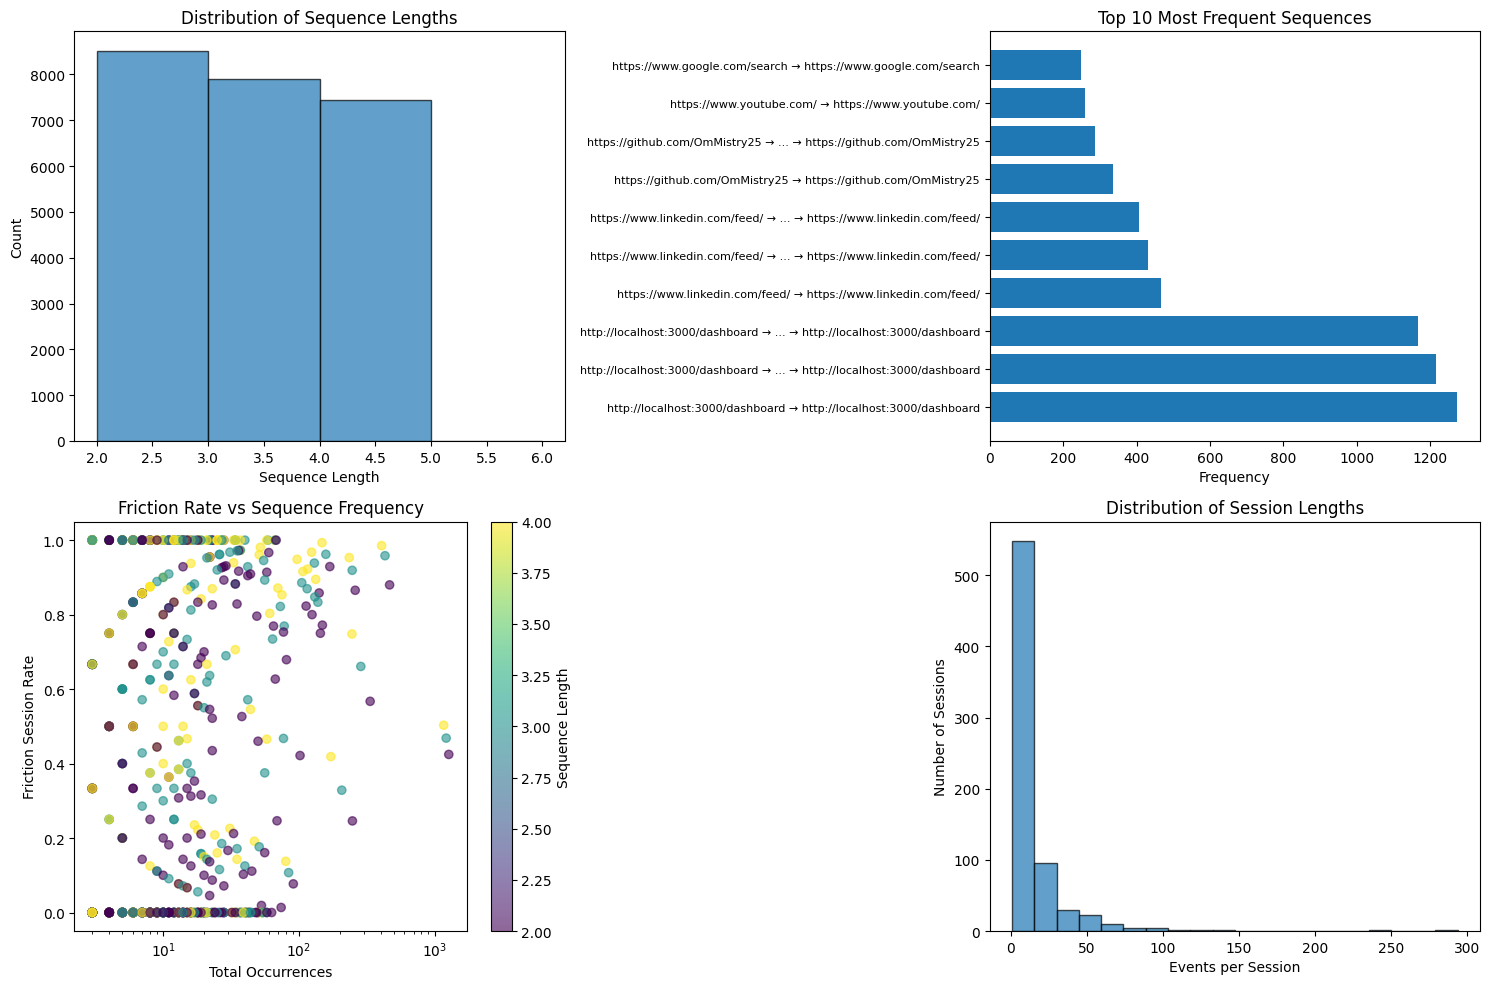

In [4]:
# Visualize sequence patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Sequence length distribution
seq_lengths = [len(seq) for seq in sequences]
axes[0,0].hist(seq_lengths, bins=range(2, 7), alpha=0.7, edgecolor='black')
axes[0,0].set_title('Distribution of Sequence Lengths')
axes[0,0].set_xlabel('Sequence Length')
axes[0,0].set_ylabel('Count')

# 2. Top sequences by frequency
top_10 = sequence_counts.most_common(10)
seq_names = [f"{seq[0]} → {seq[1]}" if len(seq) == 2 else f"{seq[0]} → ... → {seq[-1]}" for seq, _ in top_10]
counts = [count for _, count in top_10]
axes[0,1].barh(range(len(seq_names)), counts)
axes[0,1].set_yticks(range(len(seq_names)))
axes[0,1].set_yticklabels(seq_names, fontsize=8)
axes[0,1].set_title('Top 10 Most Frequent Sequences')
axes[0,1].set_xlabel('Frequency')

# 3. Friction rate vs frequency
if len(friction_analysis) > 0:
    scatter = axes[1,0].scatter(friction_analysis['total_occurrences'], 
                               friction_analysis['friction_session_rate'],
                               c=friction_analysis['length'], 
                               cmap='viridis', alpha=0.6)
    axes[1,0].set_xlabel('Total Occurrences')
    axes[1,0].set_ylabel('Friction Session Rate')
    axes[1,0].set_title('Friction Rate vs Sequence Frequency')
    axes[1,0].set_xscale('log')
    plt.colorbar(scatter, ax=axes[1,0], label='Sequence Length')

# 4. Session length distribution
session_lengths = events.groupby('session_id').size()
axes[1,1].hist(session_lengths, bins=20, alpha=0.7, edgecolor='black')
axes[1,1].set_title('Distribution of Session Lengths')
axes[1,1].set_xlabel('Events per Session')
axes[1,1].set_ylabel('Number of Sessions')

plt.tight_layout()
plt.show()


In [5]:
# Temporal analysis of sequences
def analyze_temporal_patterns(df):
    """Analyze when sequences occur throughout the day/week"""
    df['hour'] = df['ts'].dt.hour
    df['weekday'] = df['ts'].dt.day_name()
    
    # Extract sequences with timestamps
    temporal_sequences = []
    for session_id, session_data in df.groupby('session_id'):
        session_data = session_data.sort_values('ts')
        urls = session_data['url_path'].dropna().tolist()
        hours = session_data['hour'].tolist()
        weekdays = session_data['weekday'].tolist()
        
        for length in range(2, 4):
            for i in range(len(urls) - length + 1):
                temporal_sequences.append({
                    'sequence': tuple(urls[i:i+length]),
                    'hour': hours[i],
                    'weekday': weekdays[i],
                    'session_id': session_id
                })
    
    return pd.DataFrame(temporal_sequences)

temporal_data = analyze_temporal_patterns(events)

# Most common sequences by time of day
hourly_patterns = temporal_data.groupby(['hour', 'sequence']).size().reset_index(name='count')

# Get top 3 sequences per hour
top_hourly = []
for hour in sorted(hourly_patterns['hour'].unique()):
    hour_data = hourly_patterns[hourly_patterns['hour'] == hour].nlargest(3, 'count')
    top_hourly.append(hour_data)
top_hourly = pd.concat(top_hourly, ignore_index=True)

print("Top sequences by hour of day:")
for hour in sorted(top_hourly['hour'].unique()):
    hour_data = top_hourly[top_hourly['hour'] == hour]
    hour_int = int(hour)
    print(f"\n{hour_int:02d}:00 - {hour_int+1:02d}:00:")
    for _, row in hour_data.head(3).iterrows():
        seq_str = ' → '.join(row['sequence'])
        print(f"  {int(row['count']):2d}x: {seq_str}")


Top sequences by hour of day:

00:00 - 01:00:
  24x: https://claude.ai/chat/d0ee2ed8-6549-4203-a4c4-76822f5f793f → https://claude.ai/chat/d0ee2ed8-6549-4203-a4c4-76822f5f793f
  21x: https://claude.ai/chat/d0ee2ed8-6549-4203-a4c4-76822f5f793f → https://claude.ai/chat/d0ee2ed8-6549-4203-a4c4-76822f5f793f → https://claude.ai/chat/d0ee2ed8-6549-4203-a4c4-76822f5f793f
  19x: https://chatgpt.com/c/68ec483d-865c-8325-84b0-4c56615c1d33 → https://chatgpt.com/c/68ec483d-865c-8325-84b0-4c56615c1d33

01:00 - 02:00:
  181x: http://localhost:3000/dashboard → http://localhost:3000/dashboard
  175x: http://localhost:3000/dashboard → http://localhost:3000/dashboard → http://localhost:3000/dashboard
  52x: https://chatgpt.com/c/68e85e2e-f4b4-832e-8e84-1bb6312220d9 → https://chatgpt.com/c/68e85e2e-f4b4-832e-8e84-1bb6312220d9

02:00 - 03:00:
  30x: https://github.com/OmMistry25 → https://github.com/OmMistry25
  24x: https://github.com/OmMistry25 → https://github.com/OmMistry25 → https://github.com/OmMistr

In [6]:
# TIMEZONE CORRECTION
# Based on your observation: database shows 06:58 UTC but your local time is 12:31 PM CST
# This suggests a 12-hour offset in the database timestamps
# Let's add 12 hours to correct the timestamps

print("Applying timezone correction...")
print(f"Original time range: {events['ts'].min()} to {events['ts'].max()}")

# Add 12 hours to correct the offset
events['ts_corrected'] = events['ts'] + pd.Timedelta(hours=12)

print(f"Corrected time range: {events['ts_corrected'].min()} to {events['ts_corrected'].max()}")

# Update the ts column for further analysis
events['ts'] = events['ts_corrected']

# Re-run temporal analysis with corrected times
events = add_time_features(events)
events = sessionize(events, gap_minutes=30)

print("\nCorrected session statistics:")
session_stats_corrected = {
    'total_sessions': events['session_id'].nunique(),
    'avg_session_length': events.groupby('session_id').size().mean(),
    'median_session_length': events.groupby('session_id').size().median(),
    'avg_session_duration_min': (events.groupby('session_id')['ts'].max() - events.groupby('session_id')['ts'].min()).dt.total_seconds().mean() / 60,
}

for k, v in session_stats_corrected.items():
    print(f"  {k}: {v:.2f}")


Applying timezone correction...
Original time range: 2025-10-09 05:53:22.683000+00:00 to 2025-10-29 06:15:44.479000+00:00
Corrected time range: 2025-10-09 17:53:22.683000+00:00 to 2025-10-29 18:15:44.479000+00:00

Corrected session statistics:
  total_sessions: 721.00
  avg_session_length: 12.81
  median_session_length: 5.00
  avg_session_duration_min: 2.46
